In [51]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect('Formula1.sqlite')
curr = conn.cursor()

In [52]:
# Execute the query
# (This is a special query for finding the table names. You don't need to memorize it.)
curr.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
# Fetch the result and store it in table_names
table_names = curr.fetchall()
table_names

[('circuits',),
 ('races',),
 ('driver_standings',),
 ('drivers',),
 ('constructors',),
 ('results',),
 ('constructor_standings',),
 ('constructor_results',),
 ('laptimes',),
 ('pitstops',),
 ('qualifying',),
 ('seasons',),
 ('status',)]

In [53]:
pd.DataFrame(
    data=curr.execute("""SELECT * FROM races;""").fetchall(),
    columns=[x[0] for x in curr.description]
).head()

,raceId,year,round,circuitId,name,date,time,url
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


# Data Visualisation

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_28596\2189980200.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


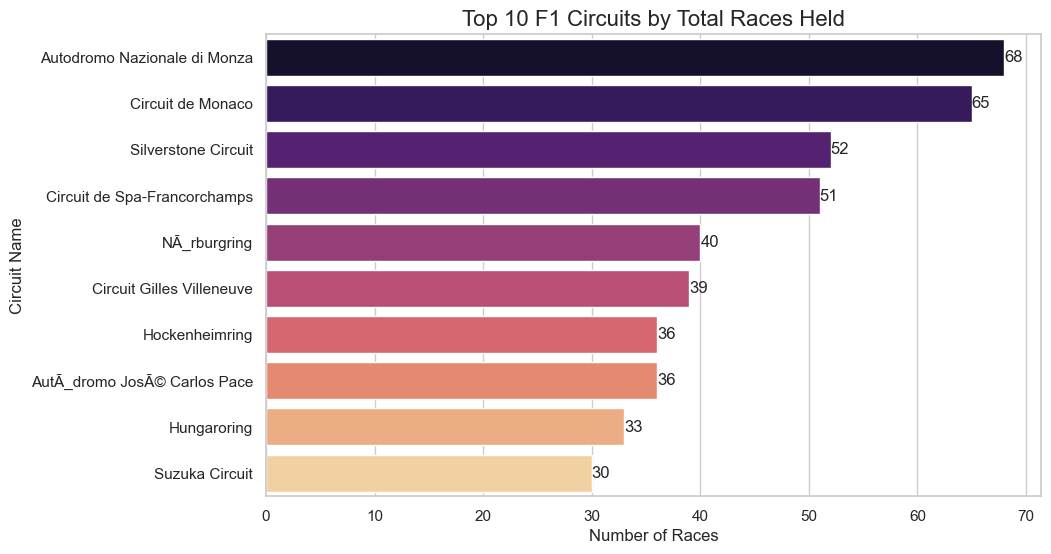

In [54]:
query = ("""SELECT 
        circuits.name, 
        COUNT(races.raceId) AS total_races
    FROM circuits
    JOIN races ON circuits.circuitId = races.circuitId
    GROUP BY circuits.name
    ORDER BY total_races DESC
    LIMIT 10 ;""")

df_plot = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the bar plot
plot = sns.barplot(
    data=df_plot, 
    x='total_races', 
    y='name', 
    palette='magma'
)

# 4. Add labels and title
plt.title('Top 10 F1 Circuits by Total Races Held', fontsize=16)
plt.xlabel('Number of Races', fontsize=12)
plt.ylabel('Circuit Name', fontsize=12)

# Optional: Add the actual numbers at the end of each bar
for i in plot.containers:
    plot.bar_label(i,)

plt.show()


C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_28596\2649682726.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


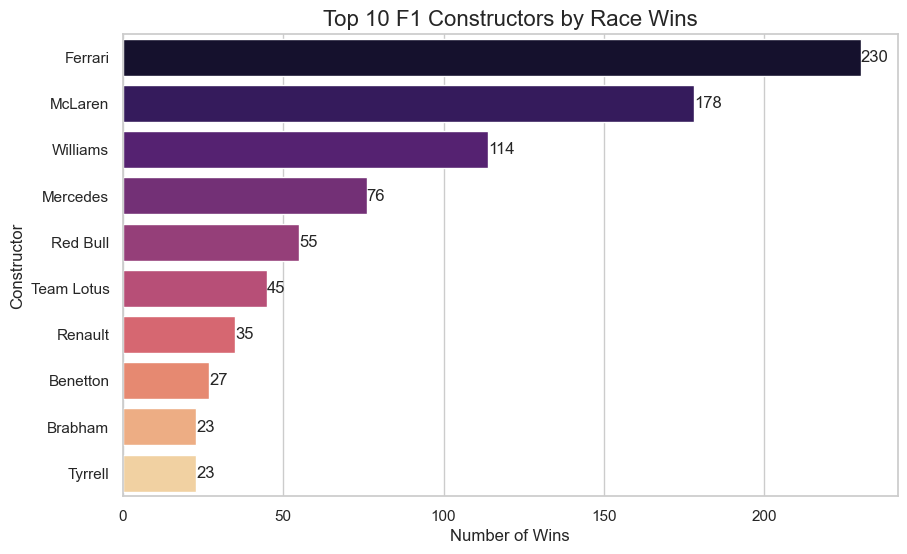

In [55]:
query = """
    SELECT 
        constructors.name AS constructor_name,
        COUNT(results.resultId) AS total_wins
    FROM constructors
    JOIN results ON constructors.constructorId = results.constructorId
    WHERE results.position = '1'
    GROUP BY constructors.constructorId
    ORDER BY total_wins DESC
    LIMIT 10;
"""

df_constructors = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_constructors,
    x='total_wins',
    y='constructor_name',
    palette='magma'
)

plt.title('Top 10 F1 Constructors by Race Wins', fontsize=16)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Constructor', fontsize=12)

for i in plot.containers:
    plot.bar_label(i)

plt.show()

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_28596\1670071109.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


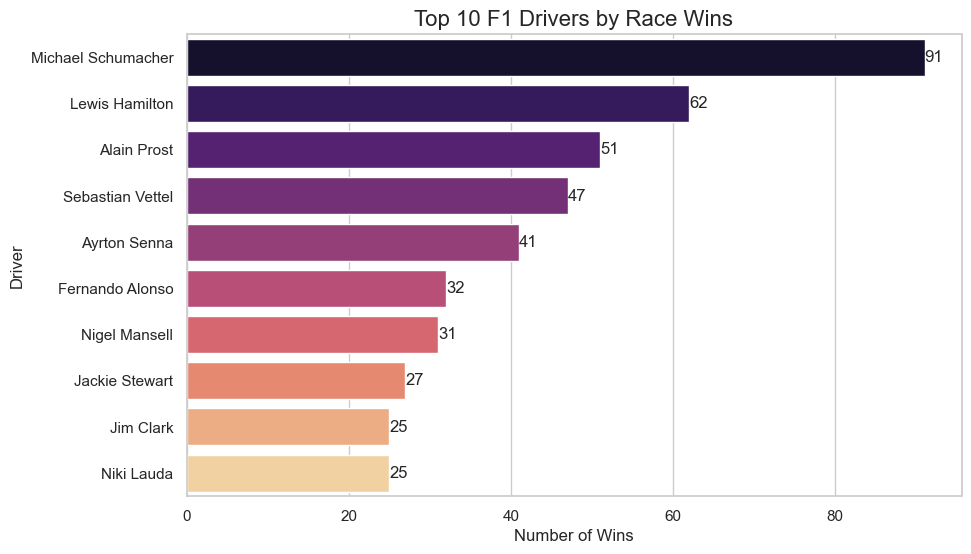

In [56]:
query = """
    SELECT 
        drivers.forename || ' ' || drivers.surname AS driver_name,
        COUNT(results.resultId) AS total_wins
    FROM drivers
    JOIN results ON drivers.driverId = results.driverId
    WHERE results.position = '1'
    GROUP BY drivers.driverId
    ORDER BY total_wins DESC
    LIMIT 10;
"""

df_drivers = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_drivers,
    x='total_wins',
    y='driver_name',
    palette='magma'
)

plt.title('Top 10 F1 Drivers by Race Wins', fontsize=16)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Driver', fontsize=12)

for i in plot.containers:
    plot.bar_label(i)

plt.show()

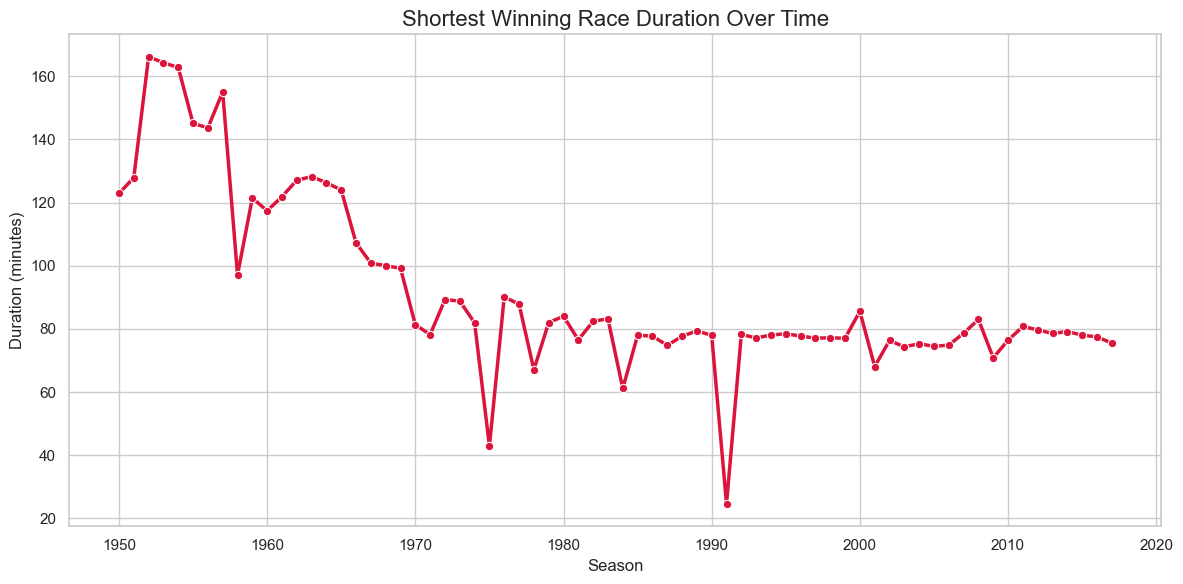

In [57]:
query = """
    SELECT 
        races.year,
        races.name AS race_name,
        MIN(results.milliseconds) / 60000.0 AS duration_minutes
    FROM results
    JOIN races ON results.raceId = races.raceId
    WHERE results.position = '1'
      AND results.milliseconds IS NOT NULL
      AND results.milliseconds != '\\N'
    GROUP BY races.year
    ORDER BY races.year ASC;
"""

df_races = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_races,
    x='year',
    y='duration_minutes',
    marker='o',
    color='crimson',
    linewidth=2.5
)

plt.title('Shortest Winning Race Duration Over Time', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)

plt.tight_layout()
plt.show()

Race durations are affected by weather, safety cars, and red flags. Shorter times may indicate a reduced-distance race.

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_28596\706305059.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


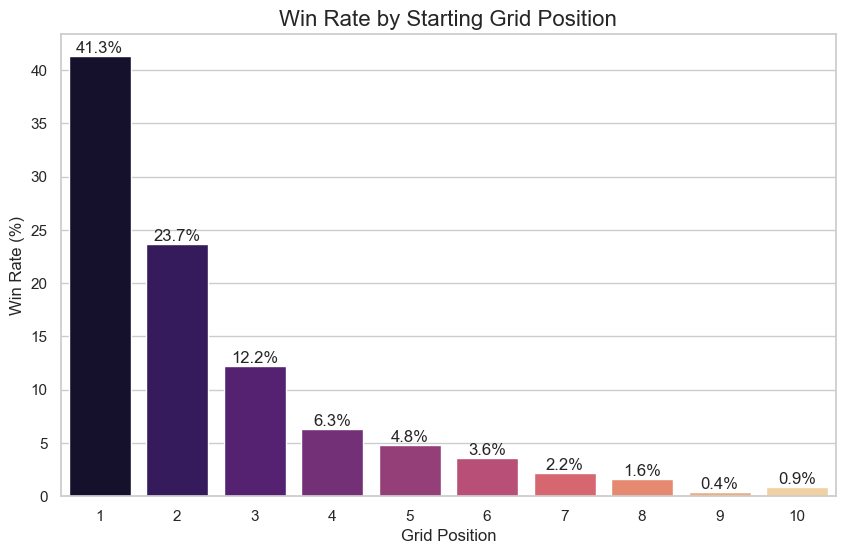

In [58]:
query = """
    SELECT
        results.grid                          AS grid_position,
        COUNT(results.resultId)               AS total_starts,
        SUM(CASE WHEN results.position = '1'
                 THEN 1 ELSE 0 END)           AS wins,
        ROUND(
            100.0 * SUM(CASE WHEN results.position = '1'
                             THEN 1 ELSE 0 END)
            / COUNT(results.resultId), 1
        )                                     AS win_pct
    FROM results
    WHERE results.grid BETWEEN 1 AND 10
      AND results.position IS NOT NULL
      AND results.position != '\\N'
    GROUP BY results.grid
    ORDER BY results.grid ASC;
"""

df_pole = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_pole,
    x='grid_position',
    y='win_pct',
    palette='magma'
)

plt.title('Win Rate by Starting Grid Position', fontsize=16)
plt.xlabel('Grid Position', fontsize=12)
plt.ylabel('Win Rate (%)', fontsize=12)

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f%%')

plt.show()

Key insight: Pole position converts to a win roughly 40% of the time — far ahead of any other grid slot. P2 wins ~19% of races, and by P5 the win rate drops below 5%. Starting from the front row gives a combined ~59% chance of winning, making qualifying performance the single biggest predictor of race outcome.

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_28596\2812127487.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


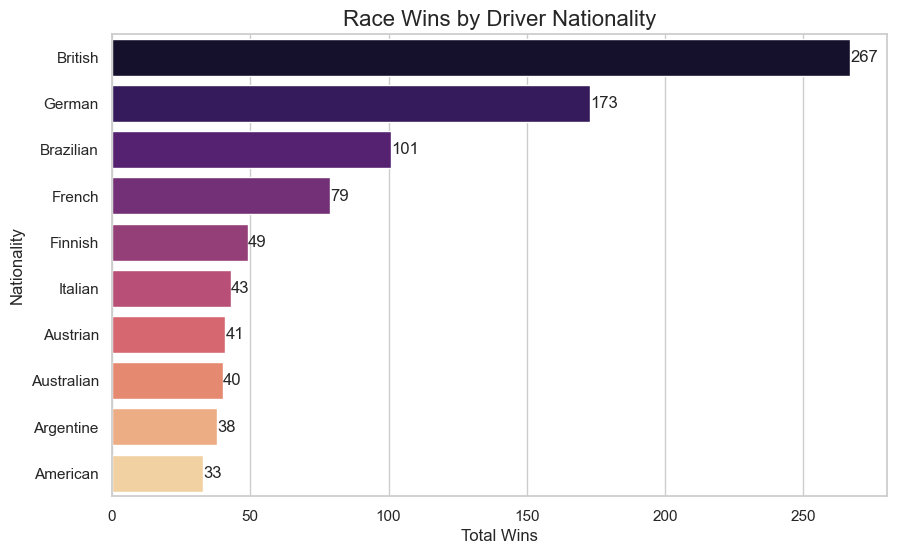

In [59]:
query = """
    SELECT
        drivers.nationality,
        COUNT(results.resultId) AS total_wins
    FROM drivers
    JOIN results ON drivers.driverId = results.driverId
    WHERE results.position = '1'
    GROUP BY drivers.nationality
    ORDER BY total_wins DESC
    LIMIT 10;
"""

df_nat = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_nat,
    x='total_wins',
    y='nationality',
    palette='magma'
)

plt.title('Race Wins by Driver Nationality', fontsize=16)
plt.xlabel('Total Wins', fontsize=12)
plt.ylabel('Nationality', fontsize=12)

for i in plot.containers:
    plot.bar_label(i)

plt.show()

Key insight: British drivers hold a commanding lead , accounting for 31% of the wins among the top ten nations. The combined success of British , German and Brazilian drivers represent the true majority totaling over 62% of all race wins in this dataset.

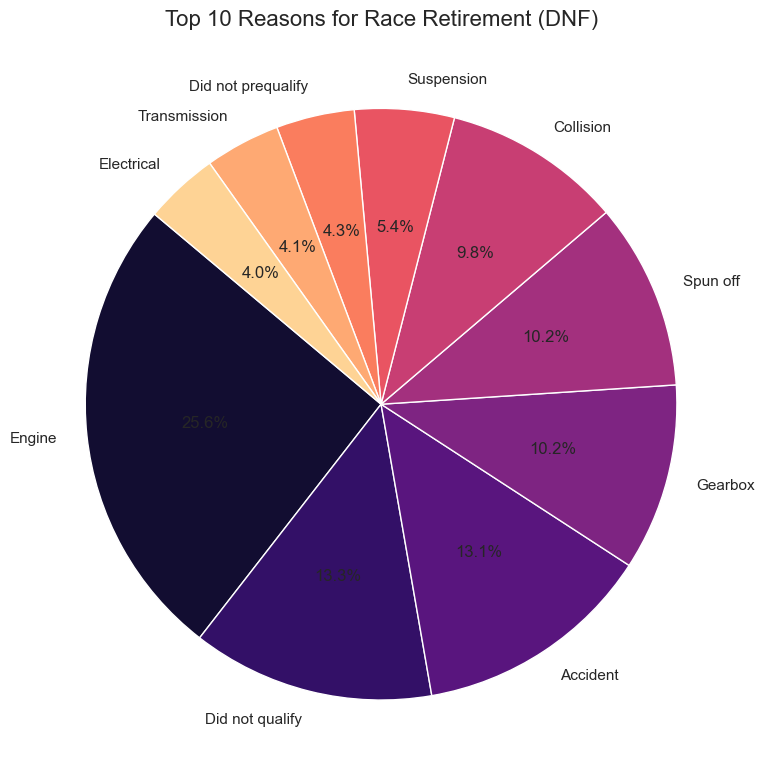

In [60]:
query = """
    SELECT
        status.status           AS reason,
        COUNT(results.resultId) AS occurrences
    FROM results
    JOIN status ON results.statusId = status.statusId
    WHERE status.status NOT IN ('Finished','+1 Lap','+2 Laps',
                                '+3 Laps','+4 Laps','+5 Laps',
                                '+6 Laps','+7 Laps','+8 Laps',
                                '+9 Laps','Disqualified','Not classified')
    GROUP BY status.status
    ORDER BY occurrences DESC
    LIMIT 10;
"""

df_dnf = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 8))

plt.pie(
    df_dnf['occurrences'],
    labels=df_dnf['reason'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('magma', len(df_dnf))
)

plt.title('Top 10 Reasons for Race Retirement (DNF)', fontsize=16)
plt.tight_layout()
plt.show()

Key insight: Mechanical failures (engine, gearbox, hydraulics) account for the majority of retirements, pointing to the immense engineering stress of racing at peak performance. Collisions — both with other cars and barriers — make up a significant chunk, especially in the midfield. The relatively low rate of electrical failures pre-2014 gives way to more electrical/hybrid system DNFs after the power unit regulation change.

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_28596\1143300911.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


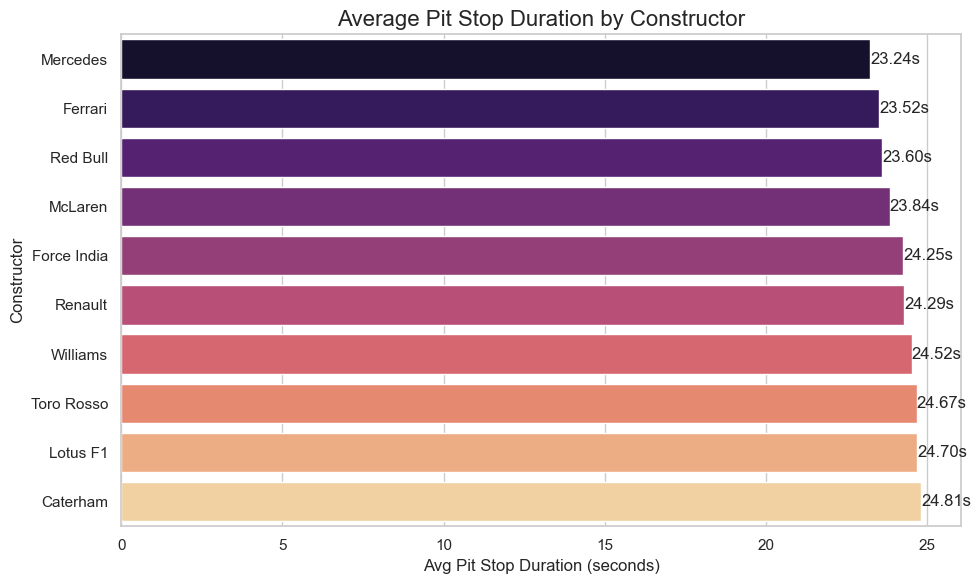

In [61]:
query = """
    SELECT
        constructors.name               AS constructor,
        COUNT(pitstops.stop)            AS total_stops,
        ROUND(AVG(pitstops.milliseconds) / 1000.0, 2)
                                        AS avg_duration_sec
    FROM pitstops
    JOIN results      ON pitstops.raceId   = results.raceId
                     AND pitstops.driverId = results.driverId
    JOIN constructors ON results.constructorId = constructors.constructorId
    WHERE pitstops.milliseconds > 0
      AND pitstops.milliseconds < 120000
    GROUP BY constructors.name
    HAVING total_stops > 100
    ORDER BY avg_duration_sec ASC
    LIMIT 10;
"""

df_pit = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_pit,
    x='avg_duration_sec',
    y='constructor',
    palette='magma'
)

plt.title('Average Pit Stop Duration by Constructor', fontsize=16)
plt.xlabel('Avg Pit Stop Duration (seconds)', fontsize=12)
plt.ylabel('Constructor', fontsize=12)

for i in plot.containers:
    plot.bar_label(i, fmt='%.2fs')

plt.tight_layout()
plt.show()

Key insight: There is a competitive 1.57-second gap between the fastest and the slowest pit stops across the field. Mercedes leads with the most efficient stops at 23.24s , followed closely by Ferrari and Redbull . While the margins appear small , these fractions of a second are critical for maintaining track position during high-pressure race scenarios.